# Lesson 9 — PyTorch Basics

This lesson introduces the four PyTorch concepts that every neural network surrogate depends on:

| Concept | What it does |
|---|---|
| **Tensor** | Data container like NumPy array — but tracks gradients |
| **Autograd** | Automatically computes `∂loss/∂params` via `backward()` |
| **`nn.Module`** | Base class for all networks — holds layers and parameters |
| **Training loop** | `zero_grad → forward → loss → backward → step` repeated |

By the end you will have a working MLP that fits the Forrester function — the exact architecture Lessons 10 and 11 will extend.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.0


In [2]:
def forrester(x):
    x = np.asarray(x).ravel()
    return (6*x - 2)**2 * np.sin(12*x - 4)

x_np = np.linspace(0, 1, 300)

## Part 1 — Tensors and NumPy interop

A **tensor** is PyTorch's core data structure. It behaves exactly like a NumPy array for math, but adds two things:
- It can live on a GPU (`tensor.cuda()`)
- It can track gradients (`requires_grad=True`)

Converting between NumPy and PyTorch is one line in each direction.

In [3]:
# Create tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(3)
c = torch.ones(3)
d = torch.linspace(0, 1, 5)
print("tensor([1,2,3]):", a)
print("zeros(3):       ", b)
print("linspace(0,1,5):", d)

# NumPy ↔ Tensor
x_np_f = np.linspace(0, 1, 200).astype(np.float32)
x_t    = torch.from_numpy(x_np_f)      # numpy → tensor (shares memory)
x_back = x_t.numpy()                   # tensor → numpy
print("\nRound-trip identical:", np.allclose(x_np_f, x_back))

# Tensor math — identical to NumPy
y_torch = torch.sin(2 * np.pi * x_t)
y_numpy = np.sin(2 * np.pi * x_np_f)
print("Max diff torch vs numpy:", np.abs(y_torch.numpy() - y_numpy).max())

tensor([1,2,3]): tensor([1., 2., 3.])
zeros(3):        tensor([0., 0., 0.])
linspace(0,1,5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

Round-trip identical: True
Max diff torch vs numpy: 5.9604645e-08


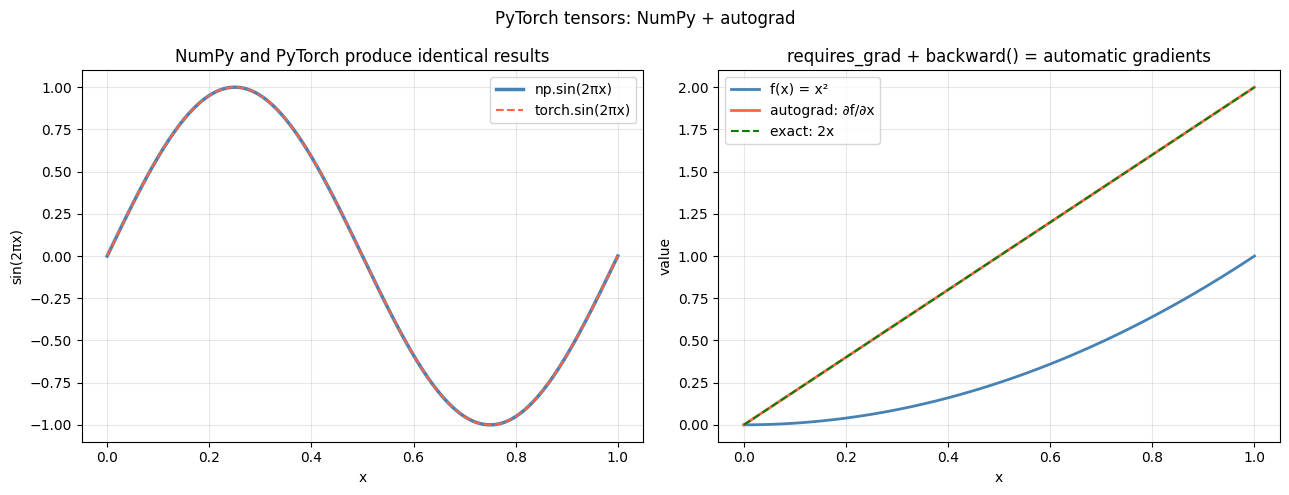

In [ ]:
# requires_grad — enable gradient tracking
x_grad = torch.linspace(0, 1, 200, requires_grad=True)
f_x    = (x_grad ** 2).sum()    # f(x) = x²,  sum so scalar for backward()
f_x.backward()                  # compute df/dx = 2x for all x
grad_vals = x_grad.grad.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_np_f, y_numpy, color="steelblue", linewidth=2.5, label="np.sin(2πx)")
axes[0].plot(x_np_f, y_torch.detach().numpy(), color="tomato",
             linewidth=1.5, linestyle="--", label="torch.sin(2πx)")
axes[0].set_title("NumPy and PyTorch produce identical results")
axes[0].set_xlabel("x"); axes[0].set_ylabel("sin(2πx)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_np_f, x_np_f**2, color="steelblue", linewidth=2, label="f(x) = x²")
axes[1].plot(x_np_f, grad_vals, color="tomato", linewidth=2, label="autograd: ∂f/∂x")
axes[1].plot(x_np_f, 2*x_np_f, color="green", linestyle="--", linewidth=1.5, label="exact: 2x")
axes[1].set_title("requires_grad + backward() = automatic gradients")
axes[1].set_xlabel("x"); axes[1].set_ylabel("value")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("PyTorch tensors: NumPy + autograd", fontsize=12)
plt.tight_layout()
plt.show()

**Key rule:** `requires_grad=True` on an input tensor → PyTorch builds a computation graph → `.backward()` populates `.grad` on all leaf tensors that contributed to the output.

During training, the **parameters** of the network are the leaf tensors. `loss.backward()` computes `∂loss/∂params` for all of them in one pass.

## Part 2 — Autograd on the Forrester function

Let's compute the gradient of the Forrester function using autograd and verify it matches finite differences.

This is the same mechanism the optimizer uses to update network weights — just applied to a simple known function so we can verify it's correct.

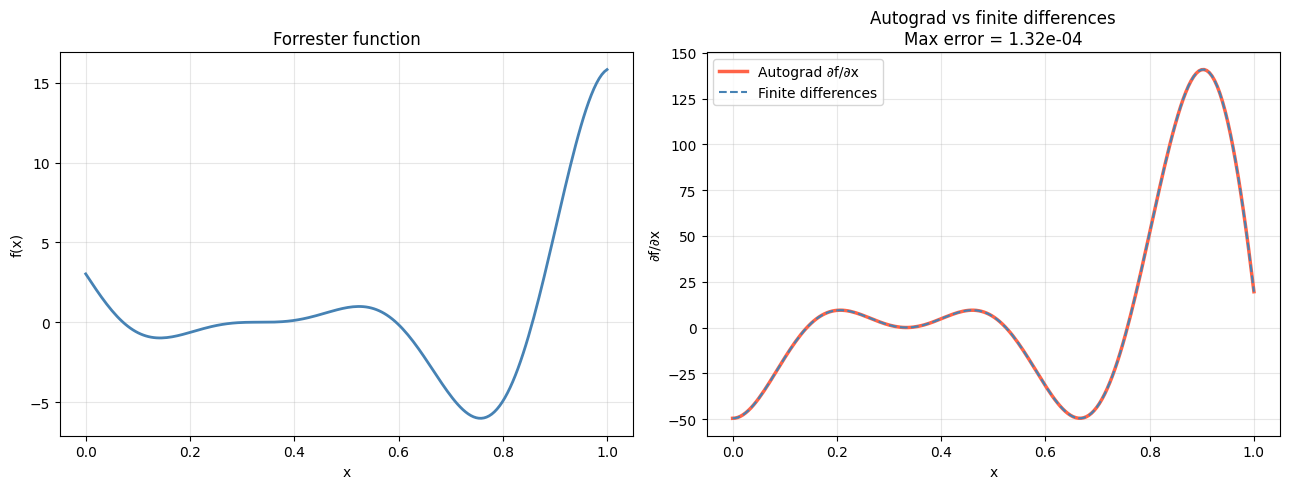

Max error between autograd and finite differences: 1.32e-04


In [5]:
# Autograd gradient
x_ag = torch.linspace(0, 1, 200, requires_grad=True)
y_ag = ((6*x_ag - 2)**2 * torch.sin(12*x_ag - 4)).sum()
y_ag.backward()
grad_ag = x_ag.grad.detach().numpy()

# Finite differences (numerical approximation)
h = 1e-5
x_np2 = np.linspace(0, 1, 200)
grad_fd = (forrester(x_np2 + h) - forrester(x_np2 - h)) / (2 * h)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_np2, forrester(x_np2), color="steelblue", linewidth=2)
axes[0].set_title("Forrester function")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_np2, grad_ag, color="tomato", linewidth=2.5, label="Autograd ∂f/∂x")
axes[1].plot(x_np2, grad_fd, color="steelblue", linestyle="--",
             linewidth=1.5, label="Finite differences")
max_err = np.abs(grad_ag - grad_fd).max()
axes[1].set_title(f"Autograd vs finite differences\nMax error = {max_err:.2e}")
axes[1].set_xlabel("x"); axes[1].set_ylabel("∂f/∂x")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Max error between autograd and finite differences: {max_err:.2e}")

**Try it:** Change `h = 1e-5` to `h = 1e-2`. The finite difference approximation gets worse. Autograd stays exact regardless.

## Part 3 — MLP architecture and the NN prior

Every neural network in PyTorch inherits from `nn.Module`. We define a two-layer MLP that will be the base for:
- **Lesson 10** — add `nn.Dropout(0.1)` after each `ReLU` → MC Dropout
- **Lesson 11** — train 5 copies of this independently → Deep Ensembles

Before training, the network outputs random predictions (determined by random weight initialisation). Plotting these is the NN equivalent of the GP prior from Lesson 5.

In [6]:
class MLP(nn.Module):
    """
    Two-layer MLP — base for MC Dropout (L10) and Deep Ensembles (L11).
    """
    def __init__(self, input_dim=1, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

# Inspect the architecture
model_demo = MLP()
print(model_demo)
n_params = sum(p.numel() for p in model_demo.parameters())
print(f"\nTotal parameters: {n_params:,}")
print("  Layer 1: 1×64 weights + 64 bias  = 128")
print("  Layer 2: 64×64 weights + 64 bias = 4160")
print("  Layer 3: 64×1 weights + 1 bias   = 65")

MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 4,353
  Layer 1: 1×64 weights + 64 bias  = 128
  Layer 2: 64×64 weights + 64 bias = 4160
  Layer 3: 64×1 weights + 1 bias   = 65


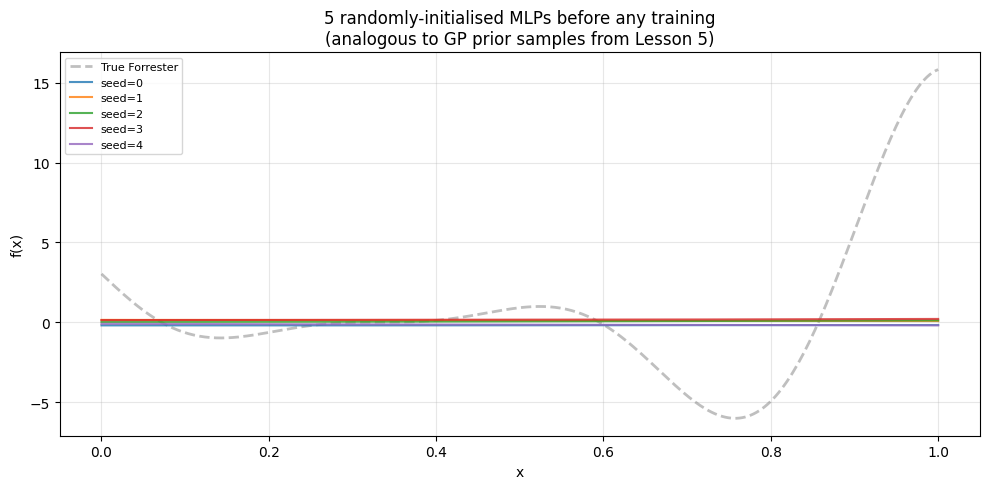

In [7]:
# Plot 5 randomly-initialised networks — the NN "prior"
x_plot = torch.from_numpy(np.linspace(0, 1, 200).astype(np.float32)).unsqueeze(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_np, forrester(x_np), color="gray", linestyle="--",
        linewidth=2, alpha=0.5, label="True Forrester")

for seed in range(5):
    torch.manual_seed(seed)
    net = MLP()
    with torch.no_grad():
        out = net(x_plot).squeeze().numpy()
    ax.plot(np.linspace(0,1,200), out, linewidth=1.5, alpha=0.8,
            label=f"seed={seed}")

ax.set_title("5 randomly-initialised MLPs before any training\n"
             "(analogous to GP prior samples from Lesson 5)")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Try it:** Change `hidden=64` to `hidden=4`. What do the random functions look like? With fewer parameters the network is more constrained.

## Part 4 — The training loop

Every training loop follows the same five-step pattern:

```
optimizer.zero_grad()      # 1. clear old gradients
pred = model(X)            # 2. forward pass
loss = loss_fn(pred, y)    # 3. compute loss
loss.backward()            # 4. backprop — fill .grad for all params
optimizer.step()           # 5. update params using .grad
```

We fit the MLP to 20 Forrester points. First we **standardize** inputs and outputs — this makes training much more stable.

In [8]:
n_train = 20
X_np  = rng.uniform(0, 1, (n_train, 1)).astype(np.float32)
y_np  = forrester(X_np).astype(np.float32)

# Standardize using training data statistics
X_mean, X_std = X_np.mean(), X_np.std()
y_mean, y_std = y_np.mean(), y_np.std()

X_tr = torch.from_numpy((X_np - X_mean) / X_std)
y_tr = torch.from_numpy((y_np - y_mean) / y_std)

print(f"X range: [{X_np.min():.2f}, {X_np.max():.2f}]  →  standardized: [{X_tr.min():.2f}, {X_tr.max():.2f}]")
print(f"y range: [{y_np.min():.2f}, {y_np.max():.2f}]  →  standardized: [{y_tr.min():.2f}, {y_tr.max():.2f}]")

X range: [0.06, 0.98]  →  standardized: [-1.84, 1.45]
y range: [-6.01, 14.69]  →  standardized: [-1.19, 3.16]


In [9]:
def train_model(model, X_tr, y_tr, X_val=None, y_val=None,
                n_epochs=3000, lr=1e-3):
    """Standard training loop — reused in Lessons 10 and 11."""
    opt     = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        pred = model(X_tr).squeeze()
        loss = loss_fn(pred, y_tr)
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

        if X_val is not None:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_val).squeeze(), y_val)
            val_losses.append(val_loss.item())

    return train_losses, val_losses

torch.manual_seed(RANDOM_SEED)
model = MLP()
train_losses, _ = train_model(model, X_tr, y_tr, n_epochs=3000)
print(f"Final train loss: {train_losses[-1]:.6f}")

Final train loss: 0.000000


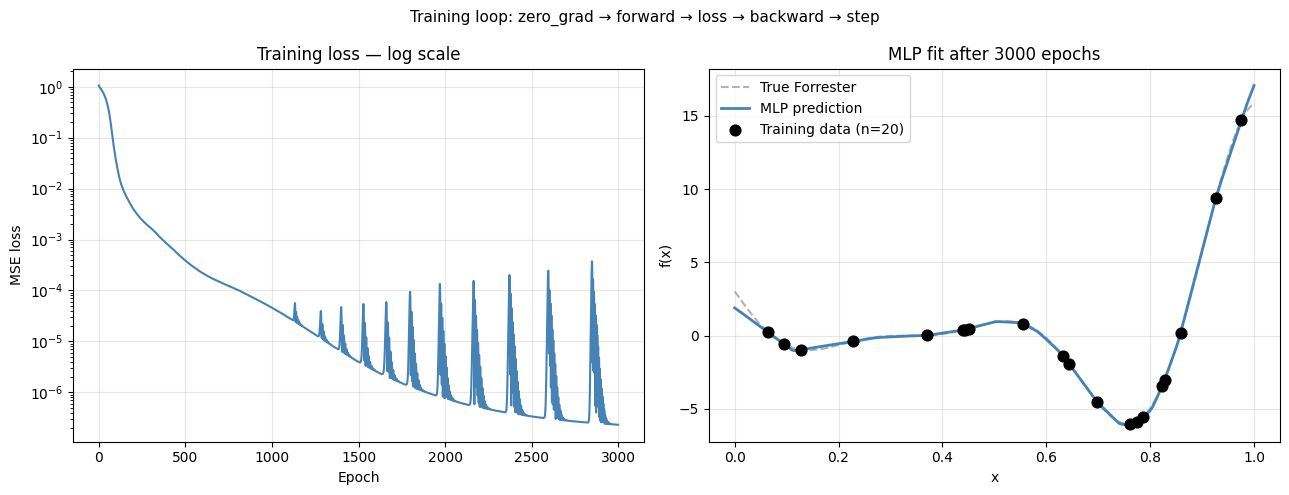

In [10]:
# Predict on dense grid (must standardize test inputs the same way)
x_dense_np = np.linspace(0, 1, 300).astype(np.float32)
x_dense_t  = torch.from_numpy((x_dense_np.reshape(-1, 1) - X_mean) / X_std)

model.eval()
with torch.no_grad():
    y_pred_std = model(x_dense_t).squeeze().numpy()
y_pred = y_pred_std * y_std + y_mean    # un-standardize

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(train_losses, color="steelblue", linewidth=1.5)
axes[0].set_title("Training loss — log scale")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_dense_np, forrester(x_dense_np), color="gray", linestyle="--",
             linewidth=1.5, alpha=0.6, label="True Forrester")
axes[1].plot(x_dense_np, y_pred, color="steelblue", linewidth=2, label="MLP prediction")
axes[1].scatter(X_np.squeeze(), y_np, color="black", s=60, zorder=5,
                label=f"Training data (n={n_train})")
axes[1].set_title(f"MLP fit after 3000 epochs")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Training loop: zero_grad → forward → loss → backward → step", fontsize=11)
plt.tight_layout()
plt.show()

**Try it:** Change `n_epochs=3000` to `n_epochs=500`. Does the fit get worse? Change `lr=1e-3` to `lr=1e-2` — does it converge faster or does it become unstable?

## Part 5 — Standardization and train/validation split

Training without standardization: the output range of Forrester is roughly [-7, 16]. The MSE loss will be large (hundreds), gradients will be large, and Adam will struggle to find a good learning rate.

Normalizing to zero mean and unit variance makes the loss start near 1.0 — a much better regime for optimization.

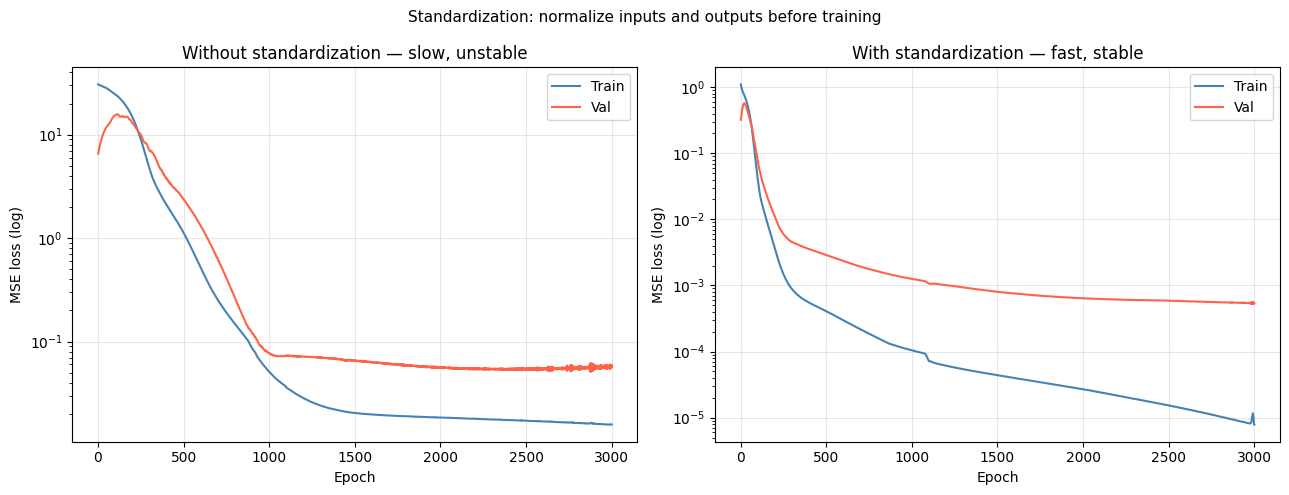

Final train loss — with std: 0.0000  without: 0.0158


In [11]:
n_total = 25
X_all = rng.uniform(0, 1, (n_total, 1)).astype(np.float32)
y_all = forrester(X_all).astype(np.float32)

n_tr = 18
X_tr_np, X_val_np = X_all[:n_tr], X_all[n_tr:]
y_tr_np, y_val_np = y_all[:n_tr], y_all[n_tr:]

# Compute stats from training set ONLY (never use val stats)
Xm, Xs = X_tr_np.mean(), X_tr_np.std()
ym, ys = y_tr_np.mean(), y_tr_np.std()

def to_t(arr): return torch.from_numpy(arr)

X_tr_t  = to_t((X_tr_np  - Xm) / Xs);  y_tr_t  = to_t((y_tr_np  - ym) / ys)
X_val_t = to_t((X_val_np - Xm) / Xs);  y_val_t = to_t((y_val_np - ym) / ys)

# With standardization
torch.manual_seed(RANDOM_SEED)
m_std = MLP()
tl_std, vl_std = train_model(m_std, X_tr_t, y_tr_t, X_val_t, y_val_t, n_epochs=3000)

# Without standardization
torch.manual_seed(RANDOM_SEED)
m_raw = MLP()
tl_raw, vl_raw = train_model(m_raw, to_t(X_tr_np), to_t(y_tr_np),
                              to_t(X_val_np), to_t(y_val_np), n_epochs=3000)

epochs = np.arange(1, 3001)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(epochs, tl_raw, color="steelblue", linewidth=1.5, label="Train")
axes[0].semilogy(epochs, vl_raw, color="tomato",   linewidth=1.5, label="Val")
axes[0].set_title("Without standardization — slow, unstable")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE loss (log)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(epochs, tl_std, color="steelblue", linewidth=1.5, label="Train")
axes[1].semilogy(epochs, vl_std, color="tomato",   linewidth=1.5, label="Val")
axes[1].set_title("With standardization — fast, stable")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MSE loss (log)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Standardization: normalize inputs and outputs before training", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Final train loss — with std: {tl_std[-1]:.4f}  without: {tl_raw[-1]:.4f}")

**Rule for NN surrogates (used in Lessons 10–11):**
1. Compute `X_mean, X_std, y_mean, y_std` from **training data only**
2. Standardize all splits with these stats
3. After predicting, **un-standardize**: `y_real = y_pred * y_std + y_mean`

## Part 6 — Save and load a model

In a real BO loop we want to save the trained surrogate and reload it without retraining. PyTorch saves only the weights (`state_dict`) — the architecture must be recreated separately.

Saved to /tmp/mlp_lesson9.pt  (20,549 bytes)
Max prediction difference after load: 0.00e+00


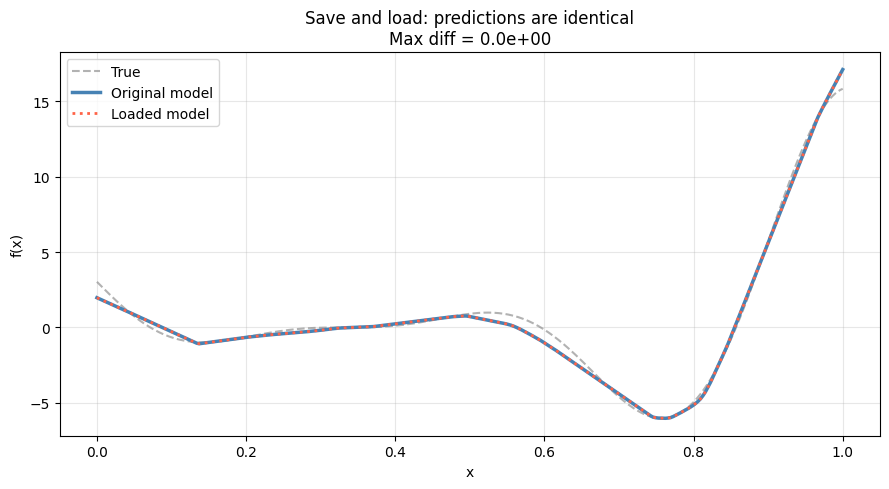

In [12]:
import tempfile, os

# Save
save_path = "/tmp/mlp_lesson9.pt"
torch.save(m_std.state_dict(), save_path)
print(f"Saved to {save_path}  ({os.path.getsize(save_path):,} bytes)")

# Load into a fresh model (different random seed to prove weights come from file)
torch.manual_seed(999)
model_loaded = MLP()
model_loaded.load_state_dict(torch.load(save_path, weights_only=True))
model_loaded.eval()

# Compare predictions
x_t = torch.from_numpy(
    ((np.linspace(0, 1, 300).astype(np.float32).reshape(-1, 1)) - Xm) / Xs
)
m_std.eval()
with torch.no_grad():
    pred_orig   = m_std(x_t).squeeze().numpy() * ys + ym
    pred_loaded = model_loaded(x_t).squeeze().numpy() * ys + ym

max_diff = np.abs(pred_orig - pred_loaded).max()
print(f"Max prediction difference after load: {max_diff:.2e}")

fig, ax = plt.subplots(figsize=(9, 5))
x_dense = np.linspace(0, 1, 300)
ax.plot(x_dense, forrester(x_dense), color="gray", linestyle="--",
        linewidth=1.5, alpha=0.6, label="True")
ax.plot(x_dense, pred_orig,   color="steelblue", linewidth=2.5, label="Original model")
ax.plot(x_dense, pred_loaded, color="tomato", linestyle=":",
        linewidth=2, label="Loaded model")
ax.set_title(f"Save and load: predictions are identical\nMax diff = {max_diff:.1e}")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

```python
# The complete pattern for NN surrogate training:

# 1. Standardize
Xm, Xs = X_train.mean(), X_train.std()
ym, ys = y_train.mean(), y_train.std()
X_t = torch.from_numpy((X_train - Xm) / Xs)
y_t = torch.from_numpy((y_train - ym) / ys)

# 2. Define model and optimizer
model = MLP(input_dim=d, hidden=64)
opt   = optim.Adam(model.parameters(), lr=1e-3)

# 3. Training loop
for epoch in range(n_epochs):
    model.train()
    opt.zero_grad()
    loss = nn.MSELoss()(model(X_t).squeeze(), y_t)
    loss.backward()
    opt.step()

# 4. Predict (un-standardize)
model.eval()
with torch.no_grad():
    y_pred = model(X_test_std).squeeze().numpy() * ys + ym
```

**Next lesson:** Add `nn.Dropout(0.1)` after each `ReLU`, keep dropout ON during inference, run 50 forward passes → mean = prediction, variance = uncertainty. That is MC Dropout.